In [1]:
# YOLOv8-seg (bed polygon) training starter
# - 목적: 180장 라벨링된 베드(segmentation)로 train/val/test split → 학습 → 결과 확인(예시 이미지 저장)
# - 가정: 원본 데이터가 YOLO 포맷으로 정리되어 있음
#   dataset_root/
#     images/   (jpg/png)
#     labels/   (txt)  # YOLO-seg polygon 포맷: cls x1 y1 x2 y2 ... (모두 0~1 정규화)
# - 주의: 현재 라벨 예시에서 class id가 18로 되어 있음. 이 스크립트는 'bed 단일 클래스' 모델을 위해
#         라벨 class를 0으로 remap하여 복사함.

from __future__ import annotations

import os
import random
import shutil
from pathlib import Path
from typing import List, Tuple

# =========================
# 0) 사용자 설정
# =========================
# TODO: 네 환경에 맞게 바꿔
DATASET_ROOT = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model")  # 여기에 images/, labels/가 있어야 함
OUT_ROOT     = Path(r"/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results")     # split 결과가 생성될 폴더

SEED = 42
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

# bed 단일 클래스 학습용 라벨 remap
SOURCE_CLASS_ID = 17
TARGET_CLASS_ID = 0


In [2]:
def list_image_stems(images_dir: Path, exts=(".jpg", ".jpeg", ".png", ".bmp", ".webp")) -> List[str]:
    stems = []
    for p in images_dir.iterdir():
        if p.is_file() and p.suffix.lower() in exts:
            stems.append(p.stem)
    stems.sort()
    return stems

def list_label_stems(labels_dir: Path) -> List[str]:
    stems = []
    for p in labels_dir.iterdir():
        if p.is_file() and p.suffix.lower() == ".txt":
            stems.append(p.stem)
    stems.sort()
    return stems

def ensure_dirs(base: Path):
    for split in ["train", "val", "test"]:
        (base / "images" / split).mkdir(parents=True, exist_ok=True)
        (base / "labels" / split).mkdir(parents=True, exist_ok=True)


def remap_label_file(src_txt: Path, dst_txt: Path, src_id: int = 18, dst_id: int = 0) -> None:
    """YOLO-seg 라벨의 클래스 id만 바꿔서 저장.
    - 한 파일에 여러 객체가 있을 수 있으므로 각 라인 첫 토큰만 확인.
    """
    if not src_txt.exists():
        # 라벨 없으면 빈 파일 생성 (학습 시 background로 취급)
        # 하지만 이 함수는 이제 매칭되는 라벨이 있는 경우에만 호출됨.
        dst_txt.write_text("", encoding="utf-8")
        return

    out_lines = []
    for line in src_txt.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        # 첫 토큰이 class id
        try:
            cls = int(float(parts[0]))
        except Exception:
            # 이상한 라인은 그대로 통과(안전)
            out_lines.append(line)
            continue

        if cls == src_id:
            parts[0] = str(dst_id)
        # 만약 다른 class가 섞여있다면 그대로 남김(혹은 여기서 제거하고 싶으면 continue 처리)
        out_lines.append(" ".join(parts))

    dst_txt.write_text("\n".join(out_lines) + ("\n" if out_lines else ""), encoding="utf-8")


def split_and_copy(dataset_root: Path, out_root: Path) -> Tuple[List[str], List[str], List[str]]:
    images_dir = dataset_root / "images_v2"
    labels_dir = dataset_root / "labels"

    assert images_dir.exists(), f"images_v2 폴더가 없음: {images_dir}"
    assert labels_dir.exists(), f"labels 폴더가 없음: {labels_dir}"

    image_stems = set(list_image_stems(images_dir))
    label_stems = set(list_label_stems(labels_dir))

    # 이미지와 라벨 이름이 모두 일치하는 경우만 선택
    common_stems = sorted(list(image_stems.intersection(label_stems)))

    if not common_stems:
        print(f"[WARN] 매칭되는 이미지-라벨 쌍이 없음. 이미지 {len(image_stems)}개, 라벨 {len(label_stems)}개")
        return [], [], [] # 매칭되는 쌍이 없으면 빈 리스트 반환

    # 제외된 파일 정보 출력
    ignored_images = len(image_stems) - len(common_stems)
    ignored_labels = len(label_stems) - len(common_stems)
    if ignored_images > 0:
        print(f"[INFO] 매칭되는 라벨이 없는 이미지 {ignored_images}개를 제외합니다.")
    if ignored_labels > 0:
        print(f"[INFO] 매칭되는 이미지가 없는 라벨 {ignored_labels}개를 제외합니다.")

    random.seed(SEED)
    random.shuffle(common_stems)

    n = len(common_stems)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # 나머지를 test로
    n_test  = n - n_train - n_val

    train_stems = common_stems[:n_train]
    val_stems   = common_stems[n_train:n_train + n_val]
    test_stems  = common_stems[n_train + n_val:]

    print(f"총 {n}장의 매칭되는 이미지-라벨 쌍 → train {len(train_stems)}, val {len(val_stems)}, test {len(test_stems)}")

    # 출력 폴더 초기화(원하면 주석 처리)
    if out_root.exists():
        shutil.rmtree(out_root)
    ensure_dirs(out_root)

    def copy_one(stem: str, split: str):
        # 이미지 복사
        src_img = None
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            cand = images_dir / f"{stem}{ext}"
            if cand.exists():
                src_img = cand
                break
        # common_stems에 있는 stem은 반드시 이미지가 존재해야 함.
        assert src_img is not None, f"[ERROR] 매칭된 이미지 '{stem}'를 찾을 수 없음. 예상치 못한 오류."

        dst_img = out_root / "images" / split / src_img.name
        shutil.copy2(src_img, dst_img)

        # 라벨 remap 복사 (common_stems에 있는 stem은 반드시 라벨이 존재해야 함)
        src_txt = labels_dir / f"{stem}.txt"
        assert src_txt.exists(), f"[ERROR] 매칭된 라벨 '{stem}.txt'를 찾을 수 없음. 예상치 못한 오류."

        dst_txt = out_root / "labels" / split / f"{stem}.txt"
        remap_label_file(src_txt, dst_txt, src_id=SOURCE_CLASS_ID, dst_id=TARGET_CLASS_ID)

    for s in train_stems:
        copy_one(s, "train")
    for s in val_stems:
        copy_one(s, "val")
    for s in test_stems:
        copy_one(s, "test")

    return train_stems, val_stems, test_stems

train_stems, val_stems, test_stems = split_and_copy(DATASET_ROOT, OUT_ROOT)

총 502장의 매칭되는 이미지-라벨 쌍 → train 401, val 50, test 51


In [3]:

# =========================
# 1-1) data.yaml 생성
# =========================

def write_data_yaml(out_root: Path, yaml_path: Path):
    # Ultralytics는 절대경로/상대경로 모두 가능
    yaml_text = f"""# YOLOv8-seg dataset config
path: {out_root.as_posix()}
train: images/train
val: images/val
test: images/test

names:
  0: bed
"""
    yaml_path.write_text(yaml_text, encoding="utf-8")
    print(f"data.yaml 저장: {yaml_path}")

DATA_YAML = OUT_ROOT / "data.yaml"
write_data_yaml(OUT_ROOT, DATA_YAML)


data.yaml 저장: /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/data.yaml


### yolo-seg 학습

In [4]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 79.5 MB/s eta 0:00:00


In [6]:
import os
import torch
from ultralytics import YOLO
from datetime import datetime

# ==========================================
# [STEP 0] 경로 및 설정 (여기만 수정하세요)
# ==========================================
PROJECT_NAME = "Lettuce_Final_Project"
RUN_NAME = f"Step1_M_Model_{datetime.now().strftime('%m%d')}"

# ==========================================
# [STEP 1] 모델 학습 (오류 수정됨)
# ==========================================
def train_lettuce_model():
    # 1. Medium 모델 로드 (Step 1 반영)
    model = YOLO("yolov8m-seg.pt")

    # 2. 학습 시작
    model.train(
        data=DATA_YAML,
        epochs=200,          # 충분한 학습 횟수
        imgsz=960,           # 고해상도
        batch=-1,            # 자동 배치 (메모리 최적화)
        device=0 if torch.cuda.is_available() else 'cpu',
        project=PROJECT_NAME,
        name=RUN_NAME,

        # [수정포인트] Step 2: mask 대신 box와 cls 가중치 조정
        # YOLOv8-seg에서 마스크 손실은 내부적으로 box 손실과 연동됩니다.
        box=10.0,            # Bounding Box 가중치 상향 (마스크 정밀도에 기여)
        cls=1.0,             # 클래스 분류 가중치

        # Step 3: 증강(Augmentation) 설정
        degrees=15.0,        # 회전 농장 특성 반영
        hsv_v=0.4,           # 조명 변화 대응 (밝기 조절)

        # 최적화
        optimizer='AdamW',
        lr0=0.001,
        cos_lr=True,         # 학습 후반부에 정교하게 수렴
        close_mosaic=20,     # 마지막 20에포크는 모자이크를 꺼서 테두리 정밀도 극대화

        exist_ok=True
    )

if __name__ == "__main__":
    train_lettuce_model()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=20, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=960, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.


0: 320x960 8 beds, 26.9ms
1: 320x960 8 beds, 26.9ms
2: 320x960 7 beds, 26.9ms
3: 320x960 7 beds, 26.9ms
4: 320x960 6 beds, 26.9ms
5: 320x960 9 beds, 26.9ms
6: 320x960 11 beds, 26.9ms
7: 320x960 8 beds, 26.9ms
Speed: 2.9ms preprocess, 26.9ms inference, 3.3ms postprocess per image at shape (1, 3, 320, 960)
Results saved to /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/pred_samples/bed_seg_v1_test_samples

[예시 예측 저장 폴더] /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/pred_samples/bed_seg_v1_test_samples


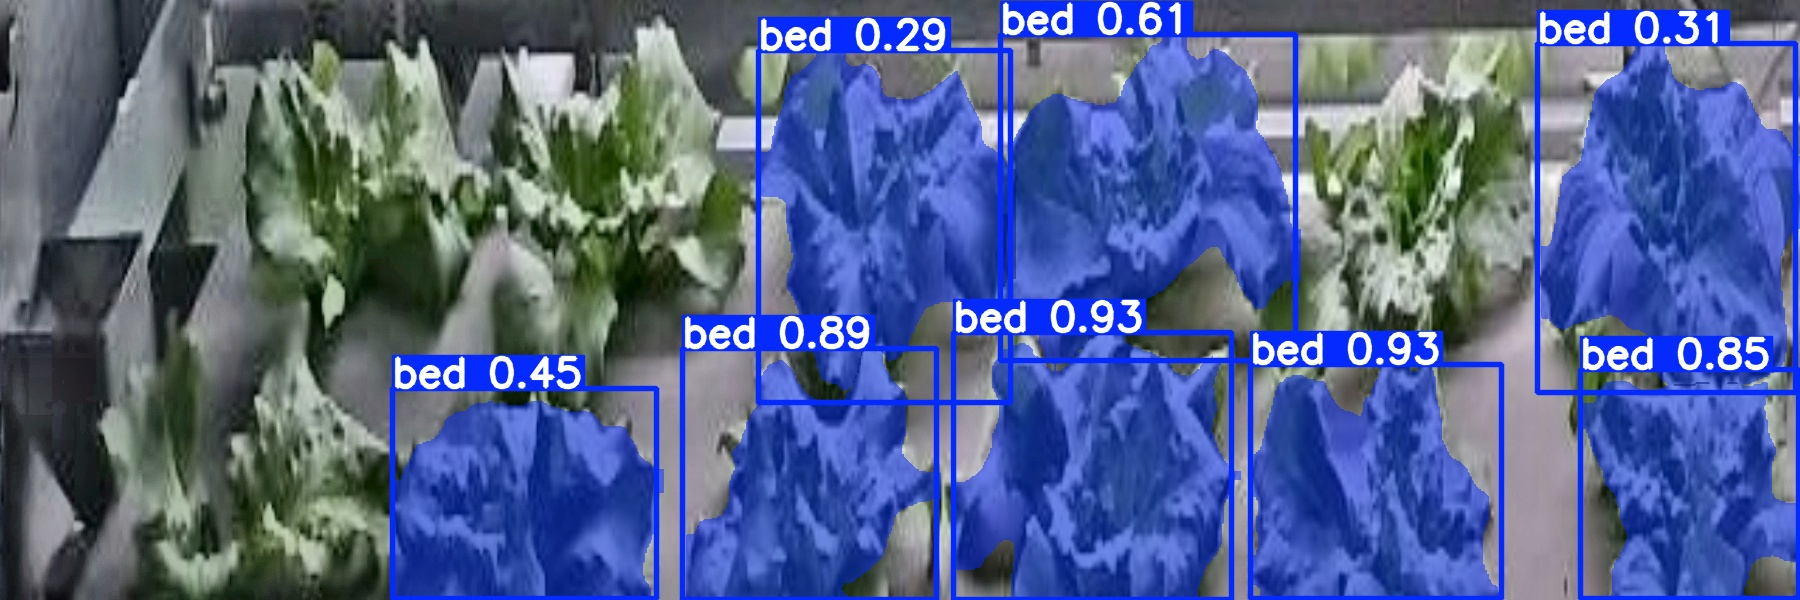

In [7]:

# =========================
# 2-2) test에서 예시 이미지 예측 & 저장
# =========================
# 원하는 만큼 뽑아서 예측 결과 이미지를 저장해 확인

import glob

best_pt = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/segment/Lettuce_Final_Project/Step1_M_Model_0312/weights/best.pt"

infer_model = YOLO(str(best_pt))

# test 이미지 중 랜덤 8장
test_images = sorted(glob.glob(str(OUT_ROOT / "images" / "test" / "*")))
random.seed(SEED)
sample_imgs = random.sample(test_images, k=min(8, len(test_images)))

PRED_DIR = OUT_ROOT / "pred_samples"
PRED_DIR.mkdir(parents=True, exist_ok=True)

pred_results = infer_model.predict(
    source=sample_imgs,
    imgsz=IMGSZ,
    conf=0.25,
    iou=0.5,
    device=DEVICE,
    save=True,
    project=str(PRED_DIR),
    name="bed_seg_v1_test_samples",
)

print("\n[예시 예측 저장 폴더]", PRED_DIR / "bed_seg_v1_test_samples")

# (Colab) 첫 예시 이미지 화면 출력
# 로컬 주피터면 아래 블록으로 확인 가능
try:
    from PIL import Image
    from IPython.display import display

    pred_img_paths = sorted((PRED_DIR / "bed_seg_v1_test_samples").glob("*.jpg"))
    if pred_img_paths:
        display(Image.open(pred_img_paths[0]))
except Exception as e:
    print("이미지 출력 생략:", e)

# =========================
# (선택) 3) 판단 기준 가이드
# =========================
# 오늘 결론을 내릴 때는 아래만 보면 됨:
# - val mAP50-95(세그) 수치가 상승 추세인지
# - val_batch*_pred.jpg에서 베드 사다리꼴이 안정적으로 잡히는지
# - 경계가 흔들리면 (1) 라벨 추가, (2) imgsz↑, (3) 모델 크기(s-seg)↑ 를 우선 고려


#반자동라벨링을 위한 나머지 라벨따기

In [ ]:
from ultralytics import YOLO
import os

# 1. 모델 로드 (G-Drive에 있는 경로로 수정해)
model = YOLO('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/results/runs/lettuce_v8s_opt2/weights/best.pt')

# 2. 이미지들이 있는 폴더와 결과 저장할 폴더 설정
input_image_path = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2'
output_txt_path = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/labels2' # 로컬 PC로 옮기기 쉽게 Colab 로컬에 일단 저장

if not os.path.exists(output_txt_path):
    os.makedirs(output_txt_path)

# 3. 추론 및 저장
# conf는 정확도 기준이야. 0.25~0.5 사이로 조정해봐.
results = model.predict(source=input_image_path, conf=0.25, save=False)

for result in results:
    # 이미지 파일명에서 확장자 제외하고 이름 추출
    img_name = os.path.splitext(os.path.basename(result.path))[0]
    txt_file_name = f"{img_name}.txt"
    save_file_path = os.path.join(output_txt_path, txt_file_name)

    with open(save_file_path, 'w') as f:
        # 결과에 세그멘테이션 마스크가 있는지 확인
        if result.masks is not None:
            # 클래스 ID와 폴리곤 좌표 가져오기
            # xyn은 이미지 크기에 맞춰 0~1로 정규화된(normalized) 좌표야.
            for mask, cls in zip(result.masks.xyn, result.labels if hasattr(result, 'labels') else result.boxes.cls):
                # 17 0.123 0.456 ... 형식으로 변환
                polygon_coords = " ".join([f"{coord:.6f}" for pair in mask for coord in pair])
                f.write(f"{int(cls)} {polygon_coords}\n")

print(f"✅ 모든 라벨링 완료! {output_txt_path} 폴더를 확인해.")


image 1/301 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2/bed20_20251129_203929_cam2.jpg: 320x960 8 beds, 58.8ms
image 2/301 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2/bed20_20251201_101010_cam2.jpg: 320x960 6 beds, 16.7ms
image 3/301 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2/bed20_20251202_072634_cam2.jpg: 320x960 6 beds, 16.8ms
image 4/301 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2/bed20_20251204_105423_cam2.jpg: 320x960 8 beds, 27.5ms
image 5/301 /content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/images2/bed20_20251206_062755_ca

In [ ]:
import os

# 1. 경로 설정 (네 환경에 맞게 수정)
label_folder = '/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/labels2'  # .txt 파일들이 들어있는 폴더

# 2. obj.names 생성 (클래스 0번에 해당하는 이름을 적어줘. 여기선 'Lettuce'라고 할게)
class_names = ['lettuce'] # 0번 클래스 이름

with open(os.path.join(label_folder, 'obj.names'), 'w') as f:
    f.write('\n'.join(class_names))

# 2. obj.data: 아주 심플하게
obj_data_content = """classes = 1
train = ./train.txt
names = ./obj.names"""
with open(os.path.join(label_folder, 'obj.data'), 'w', encoding='utf-8') as f:
    f.write(obj_data_content)

# 3. train.txt: 확장자 떼고 이름만!
txt_files = [f for f in os.listdir(label_folder) if f.endswith('.txt') and f not in ['obj.names', 'train.txt', 'obj.data']]
with open(os.path.join(label_folder, 'train.txt'), 'w', encoding='utf-8') as f:
    names_only = [os.path.splitext(x)[0] for x in txt_files]
    f.write('\n'.join(names_only))

print("🔥 마지막이다 생각하고 이걸로 다시 압축해봐!")

🔥 마지막이다 생각하고 이걸로 다시 압축해봐!


In [ ]:
import lxml.etree as ET
import os

def create_cvat_xml(label_folder, output_file):
    root = ET.Element("annotations")
    ET.SubElement(root, "version").text = "1.1"

    txt_files = [f for f in os.listdir(label_folder) if f.endswith('.txt') and len(f) > 20] # 상추 라벨 파일만 골라내기

    for txt_file in txt_files:
        img_name = os.path.splitext(txt_file)[0] + ".jpg"
        image_tag = ET.SubElement(root, "image", id="0", name=img_name, width="1800", height="600") # 크기는 네 이미지에 맞게 수정

        with open(os.path.join(label_folder, txt_file), 'r') as f:
            for line in f:
                data = line.strip().split()
                if not data: continue

                # YOLO segmentation (polygon) 형식 파싱
                points = []
                for i in range(1, len(data), 2):
                    # 정규화된 좌표를 픽셀 좌표로 복원 (1920x1080 기준)
                    x = float(data[i]) * 1800
                    y = float(data[i+1]) * 600
                    points.append(f"{x:.2f},{y:.2f}")

                ET.SubElement(image_tag, "polygon", label="lettuce", source="manual", occluded="0", points=";".join(points))

    tree = ET.ElementTree(root)
    tree.write(output_file, encoding="utf-8", xml_declaration=True, pretty_print=True)

create_cvat_xml('/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/3. ROI_LETTUCE/model/labels2/', 'lettuce_cvat.xml')